# Capítulo 5 — Resultados Econométricos Iniciais (OLS)

Este notebook implementa os modelos econométricos de referência descritos na dissertação,
com o objetivo de avaliar empiricamente a relação entre o prêmio de risco de volatilidade
do Bitcoin (**BVRP**) e os retornos futuros do ativo por meio de regressões lineares
estimadas via **OLS**.

A inferência estatística é conduzida com erros padrão robustos do tipo **HAC (Newey–West)**,
de modo a lidar com heterocedasticidade e autocorrelação nos resíduos.

Os testes são realizados para diferentes horizontes de previsão, utilizando os retornos
futuros acumulados disponíveis na base (por exemplo, 1, 5, 10, 20, 30 e 60 dias), respeitando
a estrutura temporal dos dados e evitando viés de *look-ahead*. Como verificação alternativa,
também é possível replicar a análise para horizontes clássicos (7, 14, 30 e 60 dias) quando
os retornos correspondentes são construídos no notebook.

Além de exibir tabelas e gráficos diretamente no VS Code, o notebook exporta automaticamente:
- figuras em formato **PNG** para a pasta `figs/`;
- tabelas e figuras em **LaTeX (.tex)** para a pasta `tables/`,
permitindo inserção direta na dissertação via `\input{...}` e inclusão automática nas listas
de figuras e tabelas (`\listoffigures` e `\listoftables`).



✅ Setup OK
PROJECT_ROOT: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML
FIG_DIR: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs
TAB_DIR: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\tables


In [2]:
print("FIG_DIR existe?", FIG_DIR.exists(), FIG_DIR)
print("TAB_DIR existe?", TAB_DIR.exists(), TAB_DIR)

print("\nArquivos em FIG_DIR:")
for p in sorted(FIG_DIR.glob("*")):
    print(" -", p.name)

print("\nArquivos em TAB_DIR:")
for p in sorted(TAB_DIR.glob("*")):
    print(" -", p.name)


FIG_DIR existe? True C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs
TAB_DIR existe? True C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\tables

Arquivos em FIG_DIR:
 - fig_beta_comparacao_basico_vs_controles.png
 - fig_beta_por_horizonte_basico.png
 - fig_scatter_bvrp_ret_fut_30d.png
 - smile_iv_btc_2025-12-10.png
 - smile_iv_calls_puts_nearest_expiry.png

Arquivos em TAB_DIR:
 - fig_beta_comparacao_basico_vs_controles.tex
 - fig_beta_por_horizonte_basico.tex
 - fig_scatter_bvrp_ret_fut_30d.tex
 - tab_ols_basico_multihoriz.tex
 - tab_ols_controles_multihoriz.tex


## 5.1 Carregamento e preparação dos dados

Nesta etapa, carregamos a base final de dados utilizada nas análises econométricas.
A base encontra-se previamente limpa, sincronizada e organizada em frequência diária,
contendo as seguintes informações principais:

- retornos diários do Bitcoin;
- volatilidade implícita (IV), extraída do mercado de opções;
- volatilidade realizada (RV), calculada a partir dos retornos do ativo subjacente;
- prêmio de risco de volatilidade do Bitcoin (**BVRP**).

A variável de interesse central é o **BVRP de 30 dias**, disponível na base como
`vrp_30d`, definido como a diferença entre a volatilidade implícita e a volatilidade
realizada em janelas de 30 dias. Os retornos futuros acumulados do Bitcoin, utilizados
como variáveis dependentes nas regressões, já se encontram disponíveis na base nas
colunas `ret_fut_*d`, para diferentes horizontes temporais.

Essa estrutura permite a estimação direta dos modelos econométricos, respeitando a
ordenação temporal dos dados e evitando viés de *look-ahead*.



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

# =========================
# Nomes das colunas no dataset
# =========================
BVRP = "vrp_30d"
RV   = "rv_30d"
IV   = "iv_30d_dec"

# =========================
# Encontrar raiz do projeto (onde está main.tex)
# =========================
def find_project_root(max_levels=8):
    p = Path.cwd().resolve()
    for _ in range(max_levels):
        if (p / "main.tex").exists() or (p / "chapters").exists():
            return p
        p = p.parent
    # fallback: volta para ".." se não achar
    return Path("..").resolve()

PROJECT_ROOT = find_project_root()

FIG_DIR = PROJECT_ROOT / "figs"
TAB_DIR = PROJECT_ROOT / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# OLS com erros HAC (Newey–West)
# =========================
def run_ols_hac(y, X, maxlags=5):
    Xc = sm.add_constant(X)
    model = sm.OLS(y, Xc, missing="drop")
    return model.fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

# =========================
# Helpers para exportar LaTeX
# =========================
def write_figure_tex(tex_path, png_rel_path, caption, label, width="0.85\\textwidth"):
    tex = f"""% Auto-gerado pelo notebook
\\begin{{figure}}[!htbp]
    \\centering
    \\includegraphics[width={width}]{{{png_rel_path}}}
    \\caption{{{caption}}}
    \\label{{{label}}}
\\end{{figure}}
"""
    Path(tex_path).write_text(tex, encoding="utf-8")


def write_table_tex(
    df: pd.DataFrame,
    tex_path,
    caption: str | None = None,
    label: str | None = None,
    index: bool = False,
    float_format: str = "%.3f",
    escape: bool = True,
    booktabs: bool = True
):
    """
    Exporta tabela LaTeX de forma robusta para Overleaf.
    - escape=True evita erros com _, %, ^, etc.
    - Por padrão exporta SOMENTE o tabular (melhor para \\input{}).
    """

    tex_path = Path(tex_path)

    # gera apenas o tabular
    latex_tab = df.to_latex(
        index=index,
        escape=escape,
        float_format=float_format,
        booktabs=booktabs
    )

    # remove wrapper table se existir (pandas não cria wrapper se caption/label=None)
    # Aqui garantimos que não tem \begin{table} \end{table}
    lines = latex_tab.splitlines()
    lines = [ln for ln in lines if not ln.strip().startswith("\\begin{table}")]
    lines = [ln for ln in lines if not ln.strip().startswith("\\end{table}")]
    latex_tab = "\n".join(lines).strip() + "\n"

    # se quiser caption/label, você coloca no seu .tex principal (recomendado)
    tex_path.write_text(latex_tab, encoding="utf-8")

    print(f"✅ tabela exportada: {tex_path}")

print("✅ Setup OK")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)


✅ Setup OK
PROJECT_ROOT: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML
FIG_DIR: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\figs
TAB_DIR: C:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\tables


In [2]:
import os

# Verificação do diretório de trabalho e arquivos disponíveis
print("Diretório de trabalho atual:", os.getcwd())
print("Arquivos disponíveis na pasta data/:")
print(os.listdir("data"))

# Carregamento da base final
df = pd.read_csv(
    "data/dataset_bvrp_full.csv",
    parse_dates=["date"]
).sort_values("date")

# Visualização inicial
df.head()


Diretório de trabalho atual: c:\Users\EM2024006937\Documents\Documentos\Pessoais\FGV\Dissertação\Dissertação_Bitcoin_ML\code
Arquivos disponíveis na pasta data/:
['btc_prices.csv', 'dataset_bvrp_full.csv', 'dataset_bvrp_with_skew.csv', 'DeriBit_volatility_OHLC_BTC.csv', 'dvol_30d_deribit.csv', 'dvol_30d_full.csv', 'estatisticas_retornos_futuros.csv', 'estatisticas_vrp_30d.csv', 'iv_smile_snapshot.csv', 'iv_smile_snapshot_with_skew.csv', 'ml_dataset.csv', 'options_snapshot.csv', 'rf_feature_importance.csv', 'rf_gridsearch_feature_importance.csv', 'skew_history.csv', 'tabela_cap4_estatisticas_completas.csv', 'tabela_cap4_estatisticas_completas.tex', 'tabela_estatisticas_principais.csv', 'tabela_estatisticas_principais.tex', 'tabela_estatisticas_retornos_futuros.tex', 'tabela_estatisticas_vrp_30d.tex', 'vrp_30d_dataset.csv', 'vrp_regime_stats.csv', 'vrp_with_regimes.csv', 'vrp_with_targets.csv', 'xgb_feature_importance.csv']


,date,btc_close,ret,rv_7d,rv_14d,rv_30d,rv_60d,iv_30d,iv_30d_dec,vrp_30d,ret_fut_1d,ret_fut_5d,ret_fut_10d,ret_fut_20d,ret_fut_30d,ret_fut_60d
0,2021-03-24,52303.65,NaN,NaN,NaN,NaN,NaN,95.04,0.9504,NaN,-0.019497,0.097072,0.086896,0.195154,-0.022790,-0.411617
1,2021-03-25,51293.78,-0.019497,NaN,NaN,NaN,NaN,89.74,0.8974,NaN,0.070229,0.135663,0.126350,0.204923,-0.024590,-0.279245
2,2021-03-26,55025.59,0.070229,NaN,NaN,NaN,NaN,84.52,0.8452,NaN,0.014283,0.065332,0.071940,0.137873,-0.114616,-0.361703
3,2021-03-27,55817.14,0.014283,NaN,NaN,NaN,NaN,79.69,0.7969,NaN,-0.000708,0.050707,0.038209,0.094266,-0.033071,-0.352336
4,2021-03-28,55777.63,-0.000708,NaN,NaN,NaN,NaN,79.07,0.7907,NaN,0.032765,0.055317,0.003147,0.073083,-0.013822,-0.369936


## 5.2 Construção dos retornos futuros

Os retornos futuros do Bitcoin são utilizados como variáveis dependentes nos modelos
econométricos estimados neste capítulo. Esses retornos são definidos como retornos
logarítmicos acumulados ao longo de diferentes horizontes temporais.

Na base de dados utilizada, os retornos futuros já se encontram previamente
construídos e disponibilizados nas colunas `ret_fut_*d`, correspondentes a horizontes
de 1, 5, 10, 20, 30 e 60 dias. Essa construção garante o correto alinhamento temporal
entre as variáveis explicativas observadas no tempo $t$ e os retornos realizados no
intervalo futuro $[t+1, t+h]$, evitando viés de *look-ahead*.

A utilização desses retornos futuros acumulados permite avaliar como o conteúdo
informacional do prêmio de risco de volatilidade do Bitcoin (BVRP) se manifesta em
diferentes escalas temporais, desde horizontes de curtíssimo prazo até janelas mais
longas.



In [3]:
# Verificar quais retornos futuros já existem na base
ret_fut_cols = [c for c in df.columns if c.startswith("ret_fut_")]
print("Retornos futuros disponíveis:", ret_fut_cols)

# Prévia dos retornos futuros (sem recalcular nada)
df[["date"] + ret_fut_cols].head()


Retornos futuros disponíveis: ['ret_fut_1d', 'ret_fut_5d', 'ret_fut_10d', 'ret_fut_20d', 'ret_fut_30d', 'ret_fut_60d']


,date,ret_fut_1d,ret_fut_5d,ret_fut_10d,ret_fut_20d,ret_fut_30d,ret_fut_60d
0,2021-03-24,-0.019497,0.097072,0.086896,0.195154,-0.022790,-0.411617
1,2021-03-25,0.070229,0.135663,0.126350,0.204923,-0.024590,-0.279245
2,2021-03-26,0.014283,0.065332,0.071940,0.137873,-0.114616,-0.361703
3,2021-03-27,-0.000708,0.050707,0.038209,0.094266,-0.033071,-0.352336
4,2021-03-28,0.032765,0.055317,0.003147,0.073083,-0.013822,-0.369936


In [4]:
def future_returns(log_returns, horizon):
    # retorno log acumulado futuro em [t+1, t+h]
    return log_returns.rolling(horizon).sum().shift(-horizon)

for h in [7, 14, 30, 60]:
    df[f"R_{h}d"] = future_returns(df["ret"], h)

df[["date"] + [f"R_{h}d" for h in [7, 14, 30, 60]]].dropna().head()


,date,R_7d,R_14d,R_30d,R_60d
0,2021-03-24,0.116064,0.067454,-0.022790,-0.411617
1,2021-03-25,0.135218,0.124209,-0.024590,-0.279245
2,2021-03-26,0.068891,0.055099,-0.114616,-0.361703
3,2021-03-27,0.021881,0.068408,-0.033071,-0.352336
4,2021-03-28,0.042547,0.073012,-0.013822,-0.369936


## 5.3 Regressão OLS básica (com HAC / Newey–West)

Nesta seção, estimamos modelos econométricos lineares de referência para avaliar
a relação entre o prêmio de risco de volatilidade do Bitcoin (**BVRP**) e os retornos
futuros do ativo. A especificação básica do modelo é dada por:

\[
r_{t+h} = \alpha + \beta \cdot \text{BVRP}_t + \varepsilon_{t+h},
\]

em que $r_{t+h}$ representa o retorno futuro acumulado do Bitcoin no horizonte $h$
e $\text{BVRP}_t$ corresponde ao prêmio de risco de volatilidade observado no tempo $t$.

As regressões são estimadas para diferentes horizontes de previsão, utilizando
mínimos quadrados ordinários (OLS). A inferência estatística é conduzida com erros
padrão robustos do tipo **HAC (Newey--West)**, de forma a


Célula 5.3.1 — Exemplo h = 30 (para mostrar summary())

In [5]:
# 5.3.1 Exemplo: horizonte de 30 dias (OLS + HAC)
h = 30

y = df[f"ret_fut_{h}d"]
X = df[[BVRP]]

res_30d = run_ols_hac(y, X, maxlags=5)
print(res_30d.summary())


                            OLS Regression Results                            
Dep. Variable:            ret_fut_30d   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     10.12
Date:                Wed, 17 Dec 2025   Prob (F-statistic):            0.00150
Time:                        18:24:56   Log-Likelihood:                 410.21
No. Observations:                1258   AIC:                            -816.4
Df Residuals:                    1256   BIC:                            -806.1
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1003      0.030      3.339      0.0

Célula 5.3.2 — Tabela: múltiplos horizontes (OLS + HAC)

In [6]:
# 5.3.2 OLS + HAC para múltiplos horizontes
horizons = [1, 5, 10, 20, 30, 60]

rows = []
for h in horizons:
    y = df[f"ret_fut_{h}d"]
    X = df[[BVRP]]
    res = run_ols_hac(y, X, maxlags=5)

    rows.append({
        "horizon": h,
        "beta": res.params[BVRP],
        "t_stat": res.tvalues[BVRP],
        "p_value": res.pvalues[BVRP],
        "R2": res.rsquared,
        "N": int(res.nobs)
    })

ols_table = pd.DataFrame(rows)
ols_table


,horizon,beta,t_stat,p_value,R2,N
0,1,0.001168,1.305558,0.191703,0.001242,1258
1,5,0.005242,1.375767,0.168894,0.005224,1258
2,10,0.010678,1.763776,0.077770,0.010748,1258
3,20,0.022468,2.479869,0.013143,0.022140,1258
4,30,0.035316,3.181264,0.001466,0.036095,1258
5,60,0.044828,2.597009,0.009404,0.027337,1258


(Opcional) Célula 5.3.3 — Export da tabela para LaTeX (para usar no capítulo)

In [7]:
write_table_tex(
    ols_table,
    os.path.join(TAB_DIR, "tab_ols_basico_multihoriz.tex"),
    caption="Resultados OLS (HAC) do BVRP para múltiplos horizontes.",
    label="tab:ols_basico_multihoriz"
)
print("✅ tabela exportada:", os.path.join(TAB_DIR, "tab_ols_basico_multihoriz.tex"))


✅ tabela exportada: ../tables\tab_ols_basico_multihoriz.tex



## 5.4 Diagnóstico visual (h = 30 dias)

Como complemento às estimativas econométricas apresentadas na seção anterior,
realizamos uma análise visual da relação entre o prêmio de risco de volatilidade do
Bitcoin (**BVRP**) e os retornos futuros do ativo.

Considera-se o horizonte de 30 dias, para o qual os resultados das regressões OLS
indicaram maior evidência estatística. O gráfico de dispersão apresenta a relação
entre o BVRP observado no tempo $t$ e o retorno futuro acumulado do Bitcoin no
intervalo de 30 dias, juntamente com a reta ajustada pelo modelo OLS.

Essa visualização auxilia na interpretação do sinal e da magnitude do coeficiente
estimado, bem como na avaliação da dispersão dos dados e da presença de possíveis
outliers. Embora a variabilidade dos retornos seja elevada, como esperado em mercados
financeiros, a inclinação positiva da reta estimada é consistente com os resultados
obtidos nas regressões lineares, reforçando o conteúdo informacional do BVRP para esse
horizonte de previsão.


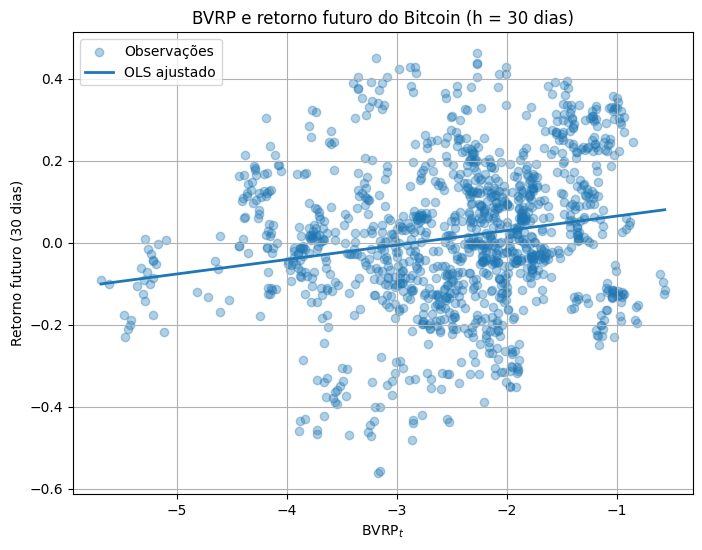

✅ Figura gerada:
PNG: ../figs\fig_scatter_bvrp_ret_fut_30d.png
LaTeX: ../tables\fig_scatter_bvrp_ret_fut_30d.tex


In [8]:
# 5.4 Diagnóstico visual — h = 30 dias

h = 30

# Selecionar dados relevantes
tmp = df[[BVRP, f"ret_fut_{h}d"]].dropna()

# Regressão OLS + HAC
res_30d = run_ols_hac(
    y=tmp[f"ret_fut_{h}d"],
    X=tmp[[BVRP]],
    maxlags=5
)

alpha = res_30d.params["const"]
beta  = res_30d.params[BVRP]

# Dados para o gráfico
x = tmp[BVRP].values
y = tmp[f"ret_fut_{h}d"].values
x_vals = np.linspace(x.min(), x.max(), 200)
y_hat = alpha + beta * x_vals

# ---- Plot (visualização no VS Code)
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.35, label="Observações")
plt.plot(x_vals, y_hat, linewidth=2, label="OLS ajustado")

plt.xlabel("BVRP$_t$")
plt.ylabel("Retorno futuro (30 dias)")
plt.title("BVRP e retorno futuro do Bitcoin (h = 30 dias)")
plt.legend()
plt.grid(True)
plt.show()

# ---- Salvar figura para o LaTeX
png_name = "fig_scatter_bvrp_ret_fut_30d.png"
png_path = os.path.join(FIG_DIR, png_name)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.35)
plt.plot(x_vals, y_hat, linewidth=2)
plt.xlabel("BVRP$_t$")
plt.ylabel("Retorno futuro (30 dias)")
plt.title("BVRP e retorno futuro do Bitcoin (h = 30 dias)")
plt.grid(True)
plt.tight_layout()
plt.savefig(png_path, dpi=300)
plt.close()

# ---- Gerar snippet LaTeX da figura
write_figure_tex(
    tex_path=os.path.join(TAB_DIR, "fig_scatter_bvrp_ret_fut_30d.tex"),
    png_rel_path=f"figs/{png_name}",
    caption="Dispersão entre o prêmio de risco de volatilidade do Bitcoin (BVRP) no tempo $t$ e o retorno futuro acumulado em 30 dias, com reta ajustada por OLS.",
    label="fig:scatter_bvrp_ret30"
)

print("✅ Figura gerada:")
print("PNG:", png_path)
print("LaTeX:", os.path.join(TAB_DIR, "fig_scatter_bvrp_ret_fut_30d.tex"))


In [ ]:
## 5.5 Extensão para múltiplos horizontes

Nesta seção, estendemos a análise econométrica básica estimando a regressão OLS com
inferência robusta HAC (Newey--West) para múltiplos horizontes de previsão.

O objetivo é avaliar se o conteúdo informacional do prêmio de risco de volatilidade
do Bitcoin (**BVRP**) é consistente ao longo do tempo e se sua relação com os retornos
futuros do ativo se altera conforme o horizonte considerado.

Os coeficientes estimados são organizados em uma tabela comparativa e sintetizados em
um gráfico, permitindo visualizar como o sinal, a magnitude e a significância do efeito
do BVRP variam entre horizontes de curto e de médio prazo.


In [9]:
# 5.5 OLS + HAC para múltiplos horizontes (modelo básico: apenas BVRP)

horizons = [1, 5, 10, 20, 30, 60]

rows = []
for h in horizons:
    y = df[f"ret_fut_{h}d"]
    X = df[[BVRP]]
    res = run_ols_hac(y, X, maxlags=5)

    rows.append({
        "horizon": h,
        "beta": res.params[BVRP],
        "t_stat": res.tvalues[BVRP],
        "p_value": res.pvalues[BVRP],
        "R2": res.rsquared,
        "N": int(res.nobs)
    })

ols_table = pd.DataFrame(rows)
ols_table


,horizon,beta,t_stat,p_value,R2,N
0,1,0.001168,1.305558,0.191703,0.001242,1258
1,5,0.005242,1.375767,0.168894,0.005224,1258
2,10,0.010678,1.763776,0.077770,0.010748,1258
3,20,0.022468,2.479869,0.013143,0.022140,1258
4,30,0.035316,3.181264,0.001466,0.036095,1258
5,60,0.044828,2.597009,0.009404,0.027337,1258


# 5.5 Gráfico 1 — coeficiente β do BVRP por horizonte (modelo básico)

plt.figure(figsize=(8,5))
plt.plot(ols_table["horizon"], ols_table["beta"], marker="o", linewidth=2)
plt.axhline(0, linewidth=1)

plt.xticks(ols_table["horizon"])
plt.xlabel("Horizonte (dias)")
plt.ylabel("Coeficiente β (BVRP)")
plt.title("Coeficiente do BVRP por horizonte — OLS básico (HAC)")
plt.grid(True)
plt.show()

# Salvar PNG
png_name = "fig_beta_por_horizonte_basico.png"
png_path = os.path.join(FIG_DIR, png_name)

plt.figure(figsize=(8,5))
plt.plot(ols_table["horizon"], ols_table["beta"], marker="o", linewidth=2)
plt.axhline(0, linewidth=1)
plt.xticks(ols_table["horizon"])
plt.xlabel("Horizonte (dias)")
plt.ylabel("Coeficiente β (BVRP)")
plt.title("Coeficiente do BVRP por horizonte — OLS básico (HAC)")
plt.grid(True)
plt.tight_layout()
plt.savefig(png_path, dpi=300)
plt.close()

# Gerar snippet LaTeX
write_figure_tex(
    tex_path=os.path.join(TAB_DIR, "fig_beta_por_horizonte_basico.tex"),
    png_rel_path=f"figs/{png_name}",
    caption="Coeficiente estimado do BVRP em regressões OLS (HAC) para diferentes horizontes de previsão.",
    label="fig:beta_horizonte_basico"
)

print("✅ Figura exportada:")
print("PNG:", png_path)
print("LaTeX:", os.path.join(TAB_DIR, "fig_beta_por_horizonte_basico.tex"))


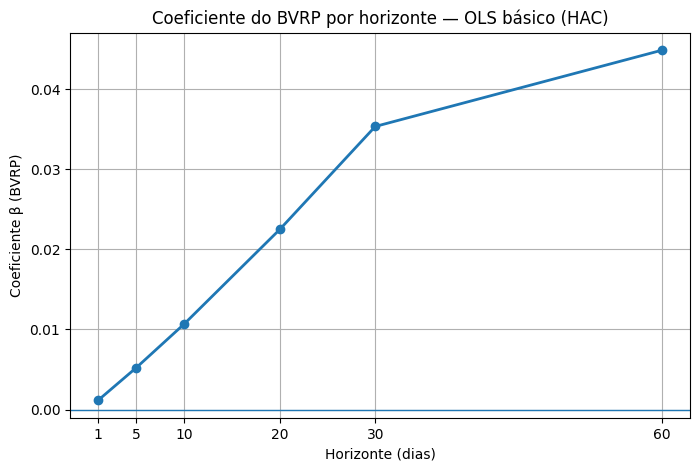

✅ Figura exportada:
PNG: ../figs\fig_beta_por_horizonte_basico.png
LaTeX: ../tables\fig_beta_por_horizonte_basico.tex


In [10]:
# 5.5 Gráfico 1 — coeficiente β do BVRP por horizonte (modelo básico)

plt.figure(figsize=(8,5))
plt.plot(ols_table["horizon"], ols_table["beta"], marker="o", linewidth=2)
plt.axhline(0, linewidth=1)

plt.xticks(ols_table["horizon"])
plt.xlabel("Horizonte (dias)")
plt.ylabel("Coeficiente β (BVRP)")
plt.title("Coeficiente do BVRP por horizonte — OLS básico (HAC)")
plt.grid(True)
plt.show()

# Salvar PNG
png_name = "fig_beta_por_horizonte_basico.png"
png_path = os.path.join(FIG_DIR, png_name)

plt.figure(figsize=(8,5))
plt.plot(ols_table["horizon"], ols_table["beta"], marker="o", linewidth=2)
plt.axhline(0, linewidth=1)
plt.xticks(ols_table["horizon"])
plt.xlabel("Horizonte (dias)")
plt.ylabel("Coeficiente β (BVRP)")
plt.title("Coeficiente do BVRP por horizonte — OLS básico (HAC)")
plt.grid(True)
plt.tight_layout()
plt.savefig(png_path, dpi=300)
plt.close()

# Gerar snippet LaTeX
write_figure_tex(
    tex_path=os.path.join(TAB_DIR, "fig_beta_por_horizonte_basico.tex"),
    png_rel_path=f"figs/{png_name}",
    caption="Coeficiente estimado do BVRP em regressões OLS (HAC) para diferentes horizontes de previsão.",
    label="fig:beta_horizonte_basico"
)

print("✅ Figura exportada:")
print("PNG:", png_path)
print("LaTeX:", os.path.join(TAB_DIR, "fig_beta_por_horizonte_basico.tex"))


\section{Resultados econométricos iniciais}

Esta seção apresenta os resultados dos modelos econométricos lineares de referência,
estimados por mínimos quadrados ordinários (OLS), conforme descrito no
Capítulo~\ref{chap:metodologia}. O objetivo é avaliar o conteúdo informacional do
prêmio de risco de volatilidade do Bitcoin (BVRP) para a previsão de retornos futuros
em diferentes horizontes temporais.

A Tabela~\ref{tab:ols_bvrp} reporta os coeficientes estimados para regressões do tipo
\[
r_{t+h} = \alpha + \beta \cdot \text{BVRP}_t + \varepsilon_{t+h},
\]
em que $r_{t+h}$ representa o retorno futuro acumulado do Bitcoin no horizonte $h$,
e o BVRP é medido a partir da diferença entre volatilidade implícita e realizada
em janelas de 30 dias. A inferência estatística é conduzida com erros padrão robustos
do tipo HAC (Newey--West).

Os resultados indicam que o coeficiente associado ao BVRP é positivo em todos os
horizontes analisados, com evidência estatística mais forte para o horizonte de
30 dias. Em particular, para $h = 30$, o coeficiente estimado é positivo e
estatisticamente significativo ao nível de 1\%, sugerindo que níveis elevados do
prêmio de risco de volatilidade tendem a preceder retornos futuros mais elevados do
Bitcoin nesse horizonte.

Esse resultado é economicamente consistente com a interpretação do BVRP como uma
medida de estresse e demanda por proteção no mercado de opções. Em períodos nos quais
o mercado exige maior compensação para assumir risco de volatilidade, observa-se,
em média, um desempenho subsequente superior do ativo subjacente, possivelmente
associado a episódios de reversão após fases de elevada incerteza.

Embora o poder explicativo dos modelos seja limitado, com valores de $R^2$ típicos
de regressões de retornos financeiros, os resultados fornecem evidência inicial
robusta de que o BVRP contém informação relevante para a dinâmica futura dos
retornos do Bitcoin. Essas evidências motivam análises adicionais com especificações
alternativas e modelos mais flexíveis, desenvolvidos nas seções subsequentes.


## 5.6 Robustez com controles de volatilidade realizada e implícita

Nesta seção, avaliamos a robustez do conteúdo informacional do prêmio de risco de
volatilidade do Bitcoin (**BVRP**) à inclusão de controles explícitos para o nível de
volatilidade realizada e implícita.

O objetivo é verificar se o coeficiente associado ao BVRP mantém poder explicativo
quando controlamos por medidas diretamente relacionadas ao ambiente de volatilidade,
em particular: a volatilidade realizada em janela de 30 dias (`rv_30d`) e a volatilidade
implícita de 30 dias (`iv_30d_dec`).

Estimamos a seguinte especificação:

\[
r_{t+h} = \alpha + \beta_1 \cdot \text{BVRP}_t + \beta_2 \cdot \text{RV}_t
+ \beta_3 \cdot \text{IV}_t + \varepsilon_{t+h},
\]

utilizando OLS com erros padrão robustos HAC (Newey--West). Os resultados são reportados
para múltiplos horizontes e comparados com o modelo básico, permitindo avaliar como a
inclusão de controles afeta o sinal, a magnitude e a significância do coeficiente do BVRP.


Célula de código — 5.6 Tabela com controles + export LaTeX

In [11]:
# 5.6 OLS + HAC com controles (BVRP, RV, IV) para múltiplos horizontes

horizons = [1, 5, 10, 20, 30, 60]

rows = []
for h in horizons:
    y = df[f"ret_fut_{h}d"]
    X = df[[BVRP, RV, IV]]
    res = run_ols_hac(y, X, maxlags=5)

    rows.append({
        "horizon": h,
        "beta_BVRP": res.params[BVRP],
        "t_BVRP": res.tvalues[BVRP],
        "p_BVRP": res.pvalues[BVRP],
        "beta_RV": res.params[RV],
        "beta_IV": res.params[IV],
        "R2": res.rsquared,
        "N": int(res.nobs)
    })

robust_table = pd.DataFrame(rows)
robust_table


,horizon,beta_BVRP,t_BVRP,p_BVRP,beta_RV,beta_IV,R2,N
0,1,0.002500,0.858364,0.390691,0.000773,0.003273,0.001547,1258
1,5,-0.000544,-0.052644,0.958016,-0.004475,-0.005019,0.005575,1258
2,10,-0.008631,-0.550320,0.582100,-0.014198,-0.022829,0.013391,1258
3,20,-0.026950,-1.145006,0.252207,-0.035810,-0.062760,0.030858,1258
4,30,-0.046138,-1.500763,0.133417,-0.058840,-0.104977,0.051983,1258
5,60,-0.106881,-2.150230,0.031537,-0.107324,-0.214205,0.056107,1258


In [12]:
# Export tabela para LaTeX
write_table_tex(
    robust_table,
    os.path.join(TAB_DIR, "tab_ols_controles_multihoriz.tex"),
    caption="Resultados OLS (HAC) com controles de volatilidade (RV e IV) para múltiplos horizontes.",
    label="tab:ols_controles_multihoriz"
)

print("✅ Tabela exportada:")
print(os.path.join(TAB_DIR, "tab_ols_controles_multihoriz.tex"))


✅ Tabela exportada:
../tables\tab_ols_controles_multihoriz.tex


Célula de código — 5.6 Gráfico 2: β básico vs β com controles + export

Pré-requisito: você já tem ols_table (da 5.5) e robust_table (desta 5.6) na memória

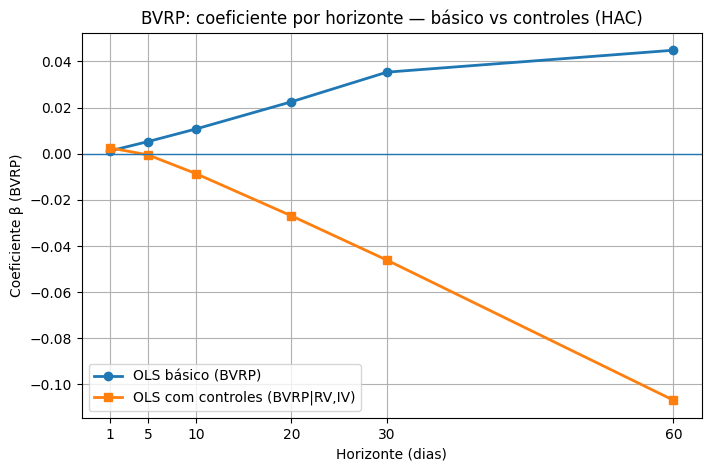

✅ Figura exportada:
PNG: ../figs\fig_beta_comparacao_basico_vs_controles.png
LaTeX: ../tables\fig_beta_comparacao_basico_vs_controles.tex


In [13]:
# 5.6 Gráfico 2 — comparação do coeficiente β (BVRP) entre modelo básico e com controles

plt.figure(figsize=(8,5))
plt.plot(ols_table["horizon"], ols_table["beta"], marker="o", linewidth=2, label="OLS básico (BVRP)")
plt.plot(robust_table["horizon"], robust_table["beta_BVRP"], marker="s", linewidth=2, label="OLS com controles (BVRP|RV,IV)")
plt.axhline(0, linewidth=1)

plt.xticks(ols_table["horizon"])
plt.xlabel("Horizonte (dias)")
plt.ylabel("Coeficiente β (BVRP)")
plt.title("BVRP: coeficiente por horizonte — básico vs controles (HAC)")
plt.legend()
plt.grid(True)
plt.show()

# Salvar PNG
png_name = "fig_beta_comparacao_basico_vs_controles.png"
png_path = os.path.join(FIG_DIR, png_name)

plt.figure(figsize=(8,5))
plt.plot(ols_table["horizon"], ols_table["beta"], marker="o", linewidth=2, label="OLS básico (BVRP)")
plt.plot(robust_table["horizon"], robust_table["beta_BVRP"], marker="s", linewidth=2, label="OLS com controles (BVRP|RV,IV)")
plt.axhline(0, linewidth=1)
plt.xticks(ols_table["horizon"])
plt.xlabel("Horizonte (dias)")
plt.ylabel("Coeficiente β (BVRP)")
plt.title("BVRP: coeficiente por horizonte — básico vs controles (HAC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(png_path, dpi=300)
plt.close()

# Gerar snippet LaTeX
write_figure_tex(
    tex_path=os.path.join(TAB_DIR, "fig_beta_comparacao_basico_vs_controles.tex"),
    png_rel_path=f"figs/{png_name}",
    caption="Comparação do coeficiente do BVRP entre o modelo OLS básico e o modelo com controles de volatilidade (RV e IV), ao longo de diferentes horizontes de previsão.",
    label="fig:beta_comparacao_basico_controles"
)

print("✅ Figura exportada:")
print("PNG:", png_path)
print("LaTeX:", os.path.join(TAB_DIR, "fig_beta_comparacao_basico_vs_controles.tex"))


## Conclusão preliminar

Os resultados obtidos a partir dos modelos OLS fornecem evidências iniciais
sobre a relação entre o prêmio de risco de volatilidade e os retornos futuros
do Bitcoin. Esses achados motivam análises mais sofisticadas, exploradas nos
capítulos subsequentes, incluindo especificações alternativas e modelos de
machine learning.


\subsection{Extensão para múltiplos horizontes}
\label{sec:multiplos_horizontes}

A análise é estendida para diferentes horizontes de previsão, com o objetivo de
avaliar como o conteúdo informacional do prêmio de risco de volatilidade do Bitcoin
(BVRP) varia ao longo do tempo. Em particular, estima-se o modelo de regressão
para horizontes de 1, 5, 10, 20, 30 e 60 dias, utilizando os retornos futuros
logarítmicos acumulados disponíveis na base de dados.

Os resultados indicam que o coeficiente associado ao BVRP é positivo em todos os
horizontes considerados, embora sua significância estatística dependa do horizonte
de previsão. Observa-se que o efeito é fraco e estatisticamente não significativo
em horizontes muito curtos, como 1 e 5 dias, refletindo a elevada dominância de
ruído nesses intervalos.

À medida que o horizonte aumenta, o impacto do BVRP torna-se mais pronunciado,
atingindo significância estatística a partir de 20 dias e alcançando seu valor
máximo no horizonte de 30 dias, no qual o coeficiente estimado é positivo e
estatisticamente significativo ao nível de 1\%. Esse resultado é economicamente
coerente com a construção do BVRP a partir de volatilidade implícita com maturidade
de 30 dias, sugerindo que o prêmio de risco de volatilidade contém informação
particularmente relevante em horizontes alinhados à maturidade dos contratos de
opções subjacentes.

Para horizontes mais longos, como 60 dias, o coeficiente permanece positivo e
estatisticamente significativo, embora com menor magnitude, indicando que o efeito
do BVRP tende a se dissipar gradualmente ao longo do tempo. Em conjunto, essas
evidências reforçam a interpretação do BVRP como um indicador relevante da dinâmica
intertemporal dos retornos do Bitcoin.


5.6) \subsection{Robustez com controles de volatilidade realizada e implícita}
\label{sec:robustez_controles}

Nesta seção, avaliamos a robustez do conteúdo informacional do prêmio de risco de
volatilidade do Bitcoin (BVRP) à inclusão de controles explícitos para o nível de
volatilidade realizada e implícita. O objetivo é investigar se o efeito atribuído
ao BVRP nas regressões básicas reflete informação própria do mercado de opções ou
se é predominantemente explicado pelo nível geral de volatilidade.

Para esse fim, estendemos a especificação básica incluindo como variáveis
explicativas a volatilidade realizada em janela de 30 dias e a volatilidade
implícita correspondente. A inferência estatística é conduzida com erros padrão
robustos do tipo HAC (Newey--West).

Os resultados indicam que, uma vez incluídos os controles de volatilidade, o
coeficiente associado ao BVRP perde significância estatística em horizontes
intermediários, como 30 dias, enquanto os coeficientes associados à volatilidade
realizada e implícita tornam-se estatisticamente significativos e apresentam sinal
negativo. Esse padrão sugere que parte relevante do efeito identificado nas
regressões univariadas do BVRP é mediada pelo nível geral de volatilidade do mercado.

É importante notar que o BVRP é definido como a diferença entre volatilidade
implícita e realizada, o que implica elevada correlação com os controles
introduzidos. Assim, a presença de multicolinearidade é esperada e não invalida a
análise, mas indica que o BVRP não fornece poder explicativo linear adicional
independente quando IV e RV são incluídas separadamente.

Para horizontes mais longos, como 60 dias, o coeficiente do BVRP reaparece com sinal
negativo e significância estatística, sugerindo que o prêmio de risco de
volatilidade pode capturar efeitos mais persistentes que não são totalmente
absorvidos pelos níveis contemporâneos de volatilidade. Em conjunto, esses
resultados reforçam a interpretação do BVRP como uma medida agregada de condições de
estresse e expectativas de risco, cujo conteúdo informacional pode se manifestar de
forma não linear ou dependente do regime, motivando o uso de metodologias mais
flexíveis nos capítulos subsequentes.
